In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller

In [25]:
df_a = yf.download('MA', start = '2020-01-01', end = '2025-01-01')['Close']['MA']
df_b = yf.download('V', start = '2020-01-01', end = '2025-01-01')['Close']['V']


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [26]:
X = sm.add_constant(df_b)

model = sm.OLS(df_a, X).fit()
beta = model.params.iloc[1]

print("Hedge Ratio:", beta)

Hedge Ratio: 1.8277176207562251


In [27]:
spread = df_a - beta*df_b

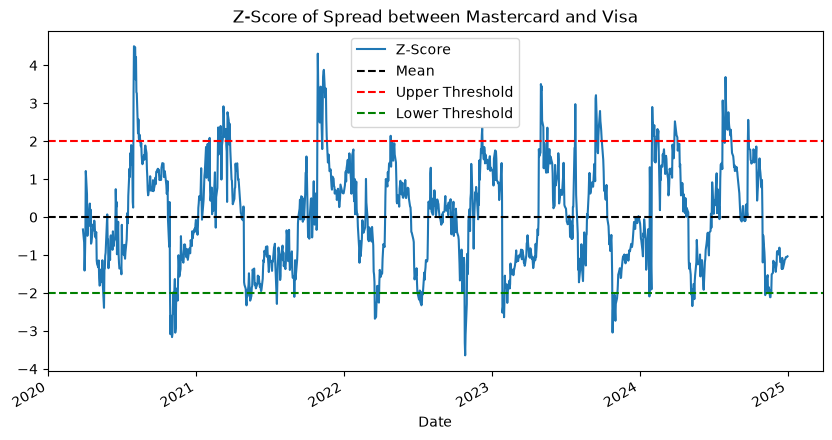

In [28]:
window = 60
rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()
z_score = (spread - rolling_mean) / rolling_std

z_score.plot(figsize = (10,5), title = "Z-Score of Spread between Mastercard and Visa")
plt.axhline(0, color = 'black', linestyle = '--')
plt.axhline(2,color = 'red', linestyle = '--')
plt.axhline(-2,color = 'green', linestyle = '--')
plt.legend(['Z-Score', 'Mean', 'Upper Threshold', 'Lower Threshold'])
plt.show()

positions = []
for z in z_score:
    if z > 2:
        positions.append(-1)  # Short position
    elif z < -2:
        positions.append(1)   # Long position
    else:
        positions.append(0)   # No position
